In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import HGate, MCXGate

In [2]:
mcx_gate = MCXGate(3)
hadamard_gate = HGate()

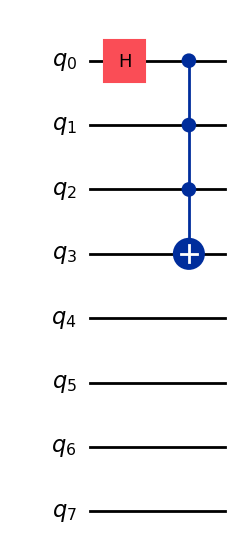

In [3]:
qc = QuantumCircuit(8)
qc.append(hadamard_gate, [0])
qc.append(mcx_gate, [0, 1, 2, 3])
qc.draw("mpl")

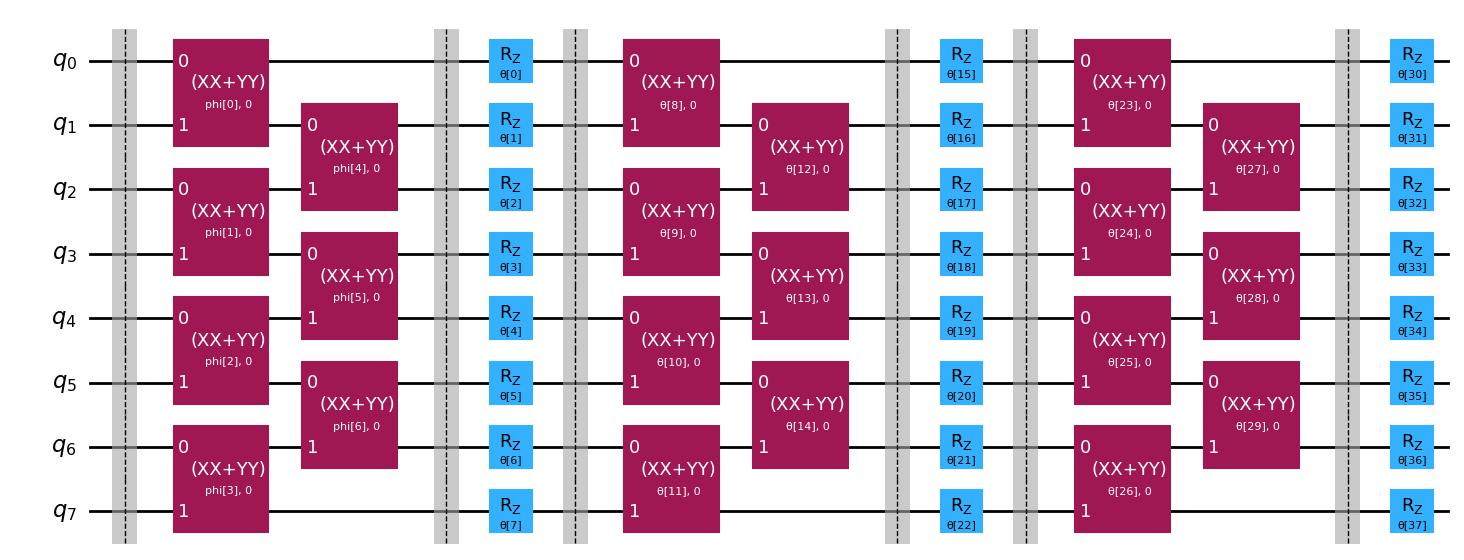

In [4]:
from qiskit.circuit.library import n_local, XXPlusYYGate, RZGate, CRXGate
from qiskit.circuit import Parameter
initial_block = n_local(num_qubits=8, rotation_blocks=[], entanglement_blocks=XXPlusYYGate(Parameter('A'),0), entanglement="pairwise", insert_barriers=True, skip_final_rotation_layer=True, reps=1, parameter_prefix="phi")
two_local = n_local(num_qubits=8, rotation_blocks="rz", entanglement_blocks=XXPlusYYGate(Parameter('A'),0), entanglement="pairwise", insert_barriers=True, reps=2)
two_local = initial_block.compose(two_local)
two_local.draw("mpl")

In [12]:
two_local.num_parameters, two_local.parameters

(45,
 ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22]), ParameterVectorElement(θ[23]), ParameterVectorElemen

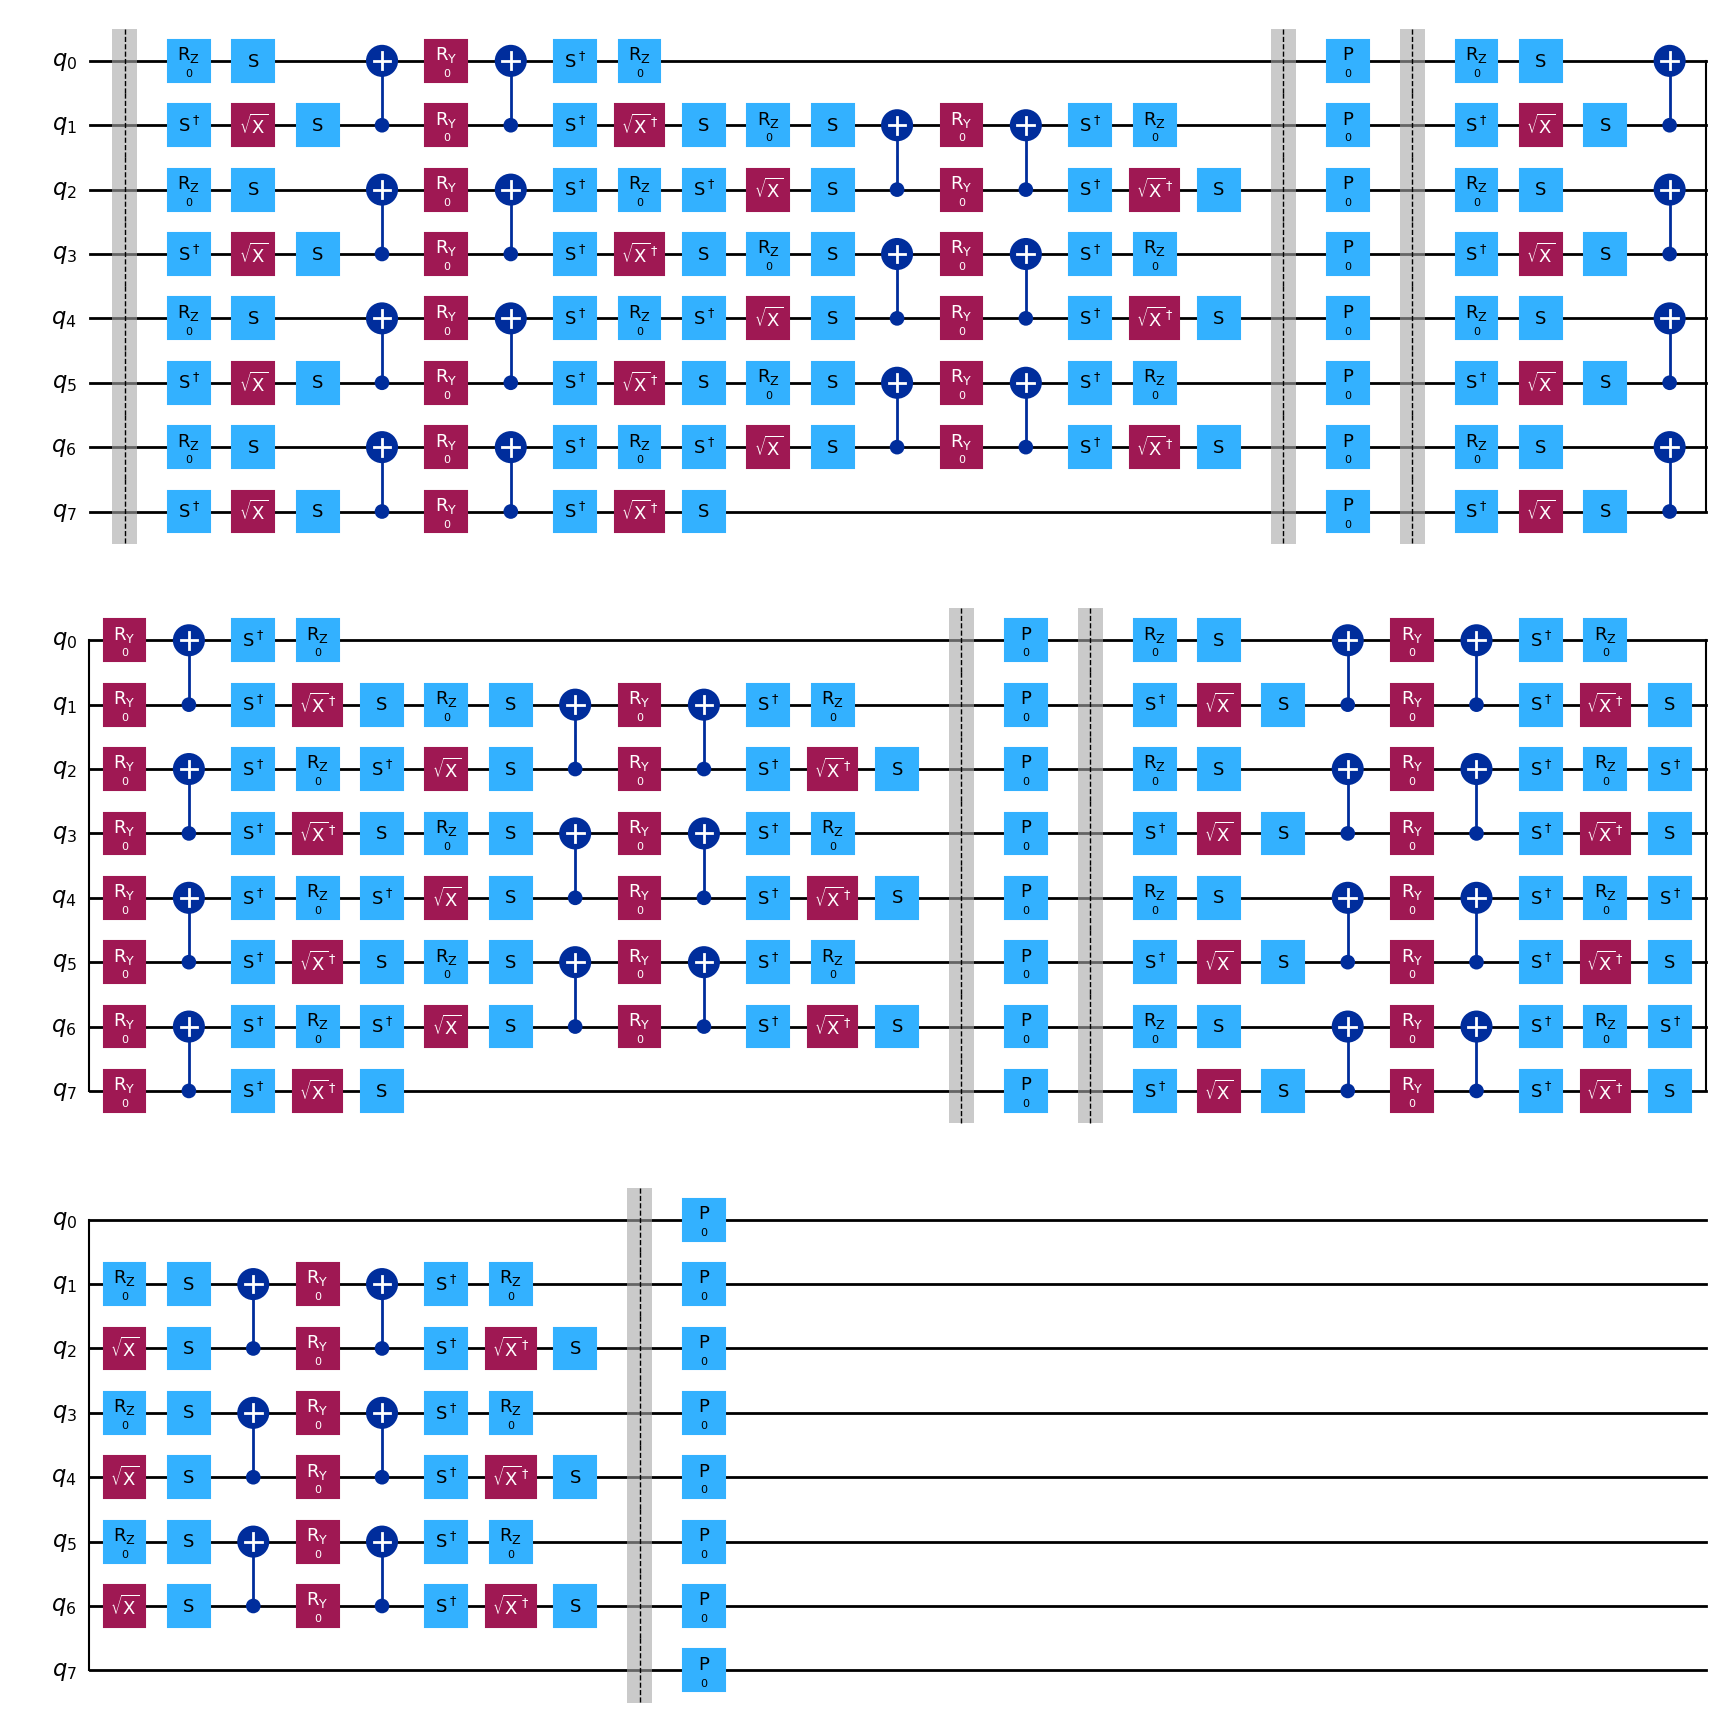

In [6]:
bound_circuit = two_local.assign_parameters(
    {p: 0 for p in two_local.parameters}
)
bound_circuit.decompose().draw("mpl")

In [7]:
qc.parameters

ParameterView([])

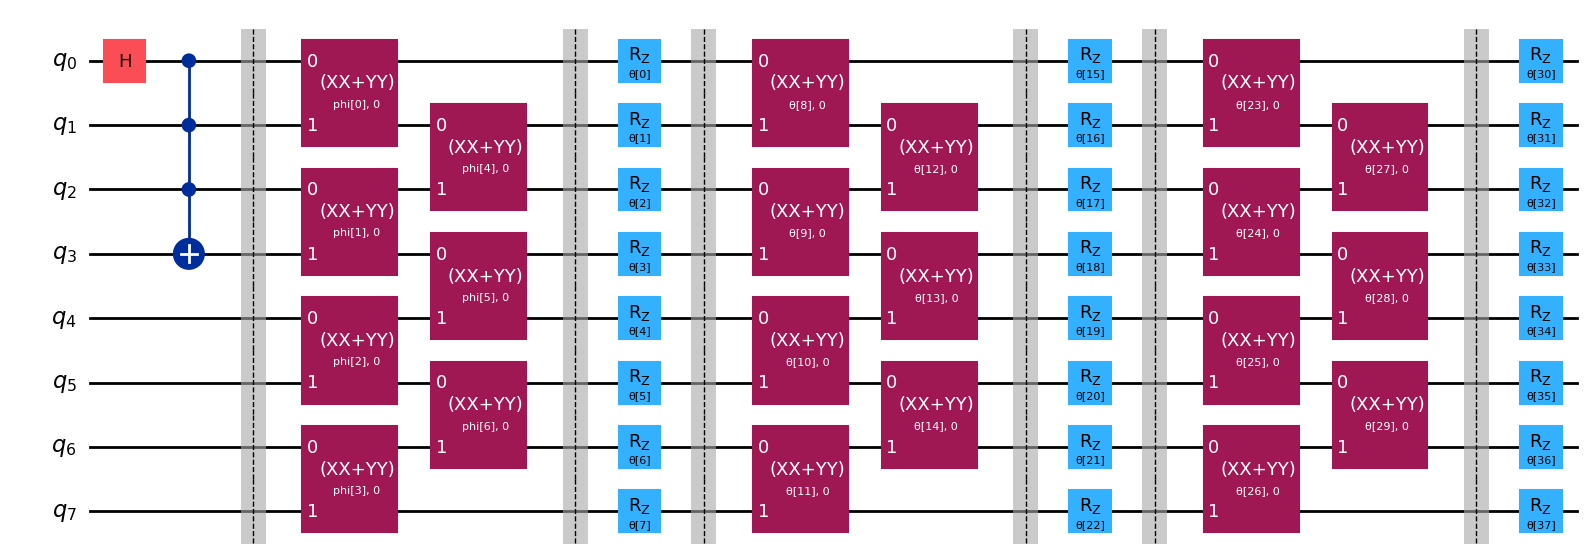

In [8]:
qc.compose(two_local, inplace=True)

qc.draw("mpl")

In [9]:
qc.parameters

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22]), ParameterVectorElement(θ[23]), ParameterVectorElement(θ[24

In [32]:
from qiskit.quantum_info import Pauli
import numpy as np

P = Pauli('-iXYZ')

print('P[0] =', repr(P[0]))
print('P[1] =', repr(P[1]))
print('P[2] =', repr(P[2]))
print('P[:] =', repr(P[:]))
print('P[::-1] =', repr(P[::-1]))
my_z = np.zeros(5, dtype=np.bool)
my_x = np.zeros(5, dtype=np.bool)
my_x[0] = True # X
my_x[1] = True # Y
my_z[1] = True # Y
my_z[2] = True # Z
my_p = Pauli((my_z, my_x, 0))
my_p

P[0] = Pauli('Z')
P[1] = Pauli('Y')
P[2] = Pauli('X')
P[:] = Pauli('XYZ')
P[::-1] = Pauli('ZYX')


Pauli('IIZYX')